In [2]:
import os
from dotenv import load_dotenv

load_dotenv()

True

In [3]:
os.environ['GOOGLE_API_KEY']=os.getenv("GEMINI_API_KEY")

In [4]:
from langchain_google_genai import ChatGoogleGenerativeAI
model=ChatGoogleGenerativeAI(model='gemini-1.5-flash')

In [5]:
model.invoke("what is the industrial growth of usa?")

AIMessage(content='The industrial growth of the USA is a complex topic spanning centuries and requiring nuance.  There\'s no single number or percentage that captures it.  Instead, we need to look at different periods and metrics:\n\n**Key Historical Periods and Trends:**\n\n* **Early Industrialization (late 18th - early 19th centuries):** This period saw the rise of textile mills, iron production, and steam power, largely fueled by the abundance of natural resources and a growing population.  Growth was significant but uneven, geographically concentrated in certain areas (e.g., New England).\n\n* **The Second Industrial Revolution (late 19th - early 20th centuries):** This era witnessed explosive growth driven by technological innovations like electricity, the Bessemer process (steel production), and the internal combustion engine.  Railroads expanded dramatically, facilitating trade and connecting markets.  This period saw the rise of massive industries and the beginnings of mass pro

In [6]:
from langchain_huggingface import HuggingFaceEmbeddings
embeddings = HuggingFaceEmbeddings(model_name="BAAI/bge-small-en")
len(embeddings.embed_query("hi"))

/opt/homebrew/Caskroom/miniconda/base/envs/agentic/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


384

In [7]:
from langchain_community.document_loaders import TextLoader, DirectoryLoader
from langchain_community.vectorstores import Chroma
from langchain.text_splitter import RecursiveCharacterTextSplitter

In [8]:
loader=DirectoryLoader("./data2",glob="./*.txt",loader_cls=TextLoader)

In [9]:
docs=loader.load()

In [10]:
docs[0].page_content

"🇺🇸 Overview of the U.S. Economy\nThe United States of America possesses the largest economy in the world in terms of nominal GDP, making it the most powerful economic force globally. It operates under a capitalist mixed economy, where the private sector dominates, but the government plays a significant regulatory and fiscal role. With a population of over 335 million people and a high level of technological advancement, the U.S. economy thrives on a foundation of consumer spending, innovation, global trade, and financial services. It has a highly diversified structure with strong sectors in technology, healthcare, finance, real estate, defense, and agriculture.\n\nU.S. GDP – Size, Composition, and Global Share\nAs of 2024, the United States’ nominal GDP is estimated to be around $28 trillion USD, accounting for approximately 25% of the global economy. It ranks #1 in the world by nominal GDP, far ahead of China (which ranks 2nd). The U.S. GDP per capita is also among the highest, hover

In [11]:
text_splitter=RecursiveCharacterTextSplitter(
    chunk_size=200,
    chunk_overlap=50
)

In [12]:
new_docs=text_splitter.split_documents(documents=docs)

In [13]:
doc_string=[doc.page_content for doc in new_docs]

In [14]:
vdb=Chroma.from_texts(
    texts=doc_string,
    embedding=embeddings,)

In [15]:
retriever =vdb.as_retriever(
    search_type="similarity",
    search_kwargs={"k": 3}
)

In [16]:
retriever.invoke("industrial growth of usa?")

[Document(metadata={}, page_content='Looking forward, the U.S. economy is expected to grow at a moderate pace, powered by innovation in AI, green energy, robotics, biotech, and quantum computing. The Biden administration’s Inflation'),
 Document(metadata={}, page_content='🇺🇸 Overview of the U.S. Economy'),
 Document(metadata={}, page_content='The U.S. economy remains the engine of global growth, backed by unmatched innovation, financial dominance, and a strong institutional framework. Its $28 trillion GDP and influence over global')]

In [26]:
import operator
from typing import List, TypedDict, Annotated, Sequence
from pydantic import BaseModel , Field
from langchain.prompts import PromptTemplate, ChatPromptTemplate
from langchain_core.runnables import RunnablePassthrough
from langchain.output_parsers import PydanticOutputParser
from langchain_core.output_parsers import StrOutputParser
from langchain_core.messages import BaseMessage
from langgraph.graph import StateGraph,END

In [18]:
class TopicSelectionParser(BaseModel):
    Topic:str=Field(description="selected topic")
    Reasoning:str=Field(description='Reasoning behind topic selection')

In [19]:
class OutputValidator(BaseModel):
    Result_Status:str=Field(description="Output response from LLM, RAG, or WEB search")
    Reasoning:str=Field(description='Reasoning behind topic selection')

In [20]:
output_parser = PydanticOutputParser(pydantic_object=OutputValidator)


In [21]:
output_parser.get_format_instructions()

'The output should be formatted as a JSON instance that conforms to the JSON schema below.\n\nAs an example, for the schema {"properties": {"foo": {"title": "Foo", "description": "a list of strings", "type": "array", "items": {"type": "string"}}}, "required": ["foo"]}\nthe object {"foo": ["bar", "baz"]} is a well-formatted instance of the schema. The object {"properties": {"foo": ["bar", "baz"]}} is not well-formatted.\n\nHere is the output schema:\n```\n{"properties": {"Result_Status": {"description": "Output response from LLM, RAG, or WEB search", "title": "Result Status", "type": "string"}, "Reasoning": {"description": "Reasoning behind topic selection", "title": "Reasoning", "type": "string"}}, "required": ["Result_Status", "Reasoning"]}\n```'

In [22]:
parser=PydanticOutputParser(pydantic_object=TopicSelectionParser)

In [23]:
parser.get_format_instructions()

'The output should be formatted as a JSON instance that conforms to the JSON schema below.\n\nAs an example, for the schema {"properties": {"foo": {"title": "Foo", "description": "a list of strings", "type": "array", "items": {"type": "string"}}}, "required": ["foo"]}\nthe object {"foo": ["bar", "baz"]} is a well-formatted instance of the schema. The object {"properties": {"foo": ["bar", "baz"]}} is not well-formatted.\n\nHere is the output schema:\n```\n{"properties": {"Topic": {"description": "selected topic", "title": "Topic", "type": "string"}, "Reasoning": {"description": "Reasoning behind topic selection", "title": "Reasoning", "type": "string"}}, "required": ["Topic", "Reasoning"]}\n```'

In [24]:
# class AgentState(TypedDict):
#     messages: Annotated[Sequence[BaseMessage], operator.add]

In [27]:
class AgentState(TypedDict):
    messages: Annotated[Sequence[BaseMessage], operator.add]
    validation_feedback: str  # Store validator feedback
    retry_count: int  # Track retry attempts
    original_question: str  # Store original question
    last_attempt: str  # Track what was tried last time

In [28]:
def function_1(state: AgentState) -> dict:
    """
    Supervisor function that handles both initial calls and restart calls from validator.
    """
    print("-> SUPERVISOR ->")

    # Check if this is a restart (validation failed)
    is_restart = state.get("validation_feedback", "") != ""
    retry_count = state.get("retry_count", 0)

    if is_restart:
        print(f"RESTART - Attempt #{retry_count}")
        print(f"Previous attempt failed: {state.get('last_attempt', 'Unknown')}")
        print(f"Validator feedback: {state.get('validation_feedback', '')}")

        question = state.get("original_question", state["messages"][0])
        feedback = state.get("validation_feedback", "")
        last_attempt = state.get("last_attempt", "")

        # Enhanced template for restart scenarios
        template = """
        RETRY SCENARIO: The previous answer was invalid and needs improvement.

        Original Question: {question}
        Previous Attempt: {last_attempt}
        Validation Feedback: {feedback}
        Retry Count: {retry_count}

        Based on the feedback, classify the query into one of: [USA, WEB_SEARCH, LLM_GENERATION]

        Consider:
        - If previous attempt was RAG (USA) and failed, try WEB_SEARCH or LLM_GENERATION
        - If previous attempt was LLM_GENERATION and failed, try WEB_SEARCH or USA
        - If previous attempt was WEB_SEARCH and failed, try LLM_GENERATION or USA

        Choose a DIFFERENT approach than the previous attempt.

        {format_instructions}
        """

        prompt = PromptTemplate(
            template=template,
            input_variables=["question", "last_attempt", "feedback", "retry_count"],
            partial_variables={"format_instructions": parser.get_format_instructions()}
        )

        response = (prompt | model | parser).invoke({
            "question": question,
            "last_attempt": last_attempt,
            "feedback": feedback,
            "retry_count": retry_count
        })

    else:
        # Initial call - normal classification
        question = state["messages"][-1]
        print(f"INITIAL CALL - Question: {question}")

        template = """
        Your task is to classify the topic from the given categories: [USA, WEB_SEARCH, LLM_GENERATION].
        Only respond with the category name and reasoning.

        User query: {question}
        {format_instructions}
        """

        prompt = PromptTemplate(
            template=template,
            input_variables=["question"],
            partial_variables={"format_instructions": parser.get_format_instructions()}
        )

        response = (prompt | model | parser).invoke({"question": question})

    print(f"Supervisor decision: {response.Topic}")

    return {
        "messages": [response.Topic],
        "original_question": question,
        "last_attempt": response.Topic,
        "validation_feedback": "",  # Clear previous feedback
    }

In [29]:
# def function_1(state: AgentState) -> str:
#     """    Function to process the agent state and return a string.
#     """
#     question = state['messages'][-1]
#     print(f"Processing messages (last question from queue): {question}")

#     template = """
#     Your task is to classify the topic from the given categories. [USA, WEB_SEARCH, LLM_GENERATION].
#     Only respond with the category name and nothing else.
#     User query: {question}
#     {format_instructions}
#     """

#     prompt= PromptTemplate(
#         template=template,
#         input_variable=["question"],
#         partial_variables={"format_instructions": parser.get_format_instructions()}
#     )

#     chain= prompt | model | parser
#     response = chain.invoke(
#        {"question": question}
#     )
#     print("Parsed response:", response)
#     return {"messages": [response.Topic]}

In [30]:
state={"messages":["what is a today weather?"]}

In [31]:
function_1(state)

-> SUPERVISOR ->
INITIAL CALL - Question: what is a today weather?
Supervisor decision: WEB_SEARCH


{'messages': ['WEB_SEARCH'],
 'original_question': 'what is a today weather?',
 'last_attempt': 'WEB_SEARCH',
 'validation_feedback': ''}

In [32]:
def router(state: AgentState) -> str:
    """Router function to determine which function to call based on the agent state."""
    print("-> ROUTER ->")

    last_message = state['messages'][-1]

    print(f"Last message: {last_message}")

    if "usa" in last_message.lower():
        return "RAG Call"
    elif "web_search" in last_message.lower():
        return "WEB CRAWLER Call"
    elif "llm_generation" in last_message.lower():
        return "LLM Call"

In [33]:
def format_docs(docs):
    """Format the documents into a string."""
    return "\n".join([doc.page_content for doc in docs])

In [34]:
# RAG Function
def function_2(state: AgentState) -> str:
    """Function to process the agent state and return a string."""
    question = state['messages'][0]
    prompt = PromptTemplate(
        template="""
        you are the assistant for question-answering tasks. Use the following
        pieces of retievered context to answer the question. If you don't know the answer,
        just say that you don't know. Don't try to make up an answer. Use three maximum
        and keep the answer concise.\nQuestion: {question} \nContext: {context} \nAnswer:""",

        input_variables=["context","question"]
    )
    rag_chain = (
        {"context": retriever | format_docs, "question": RunnablePassthrough() }
        | prompt
        | model
        | StrOutputParser()  # Ensure the output is clean
    )
    result = rag_chain.invoke(question)
    print("Response from function_2:", result)
    return {"messages": [result]}

In [35]:
state = {"messages": ["What is the industrial growth of USA?"]}

In [36]:
function_2(state)

Response from function_2: The U.S. economy is the engine of global growth, with a $28 trillion GDP.  Growth is driven by innovation in AI, green energy, robotics, biotech, and quantum computing.  It maintains growth through strong innovation, entrepreneurship, and R&D investment.


{'messages': ['The U.S. economy is the engine of global growth, with a $28 trillion GDP.  Growth is driven by innovation in AI, green energy, robotics, biotech, and quantum computing.  It maintains growth through strong innovation, entrepreneurship, and R&D investment.']}

In [37]:
state = {"messages": ["What is the weather today?"]}

In [38]:
function_2(state)

Response from function_2: I don't know.


{'messages': ["I don't know."]}

In [39]:
# LLM Function
def function_3(state:AgentState):
    print("-> LLM Call ->")
    question = state["messages"][0]

    # Normal LLM call
    complete_query = "Answer the follow question with your knowledge of the real world. Following is the user question: " + question
    response = model.invoke(complete_query)
    return {"messages": [response.content]}

In [40]:
def function_4(state: AgentState):
    """
    Uses the Tavily API to perform a web search/crawl for the given query using LangChain chain.
    """
    print("-> WEB Search ->")
    from langchain_community.tools.tavily_search import TavilySearchResults

    question = state["messages"][0]

    # Initialize Tavily tool
    tavily_tool = TavilySearchResults(
        tavily_api_key="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",
        max_results=3
    )

    # Create a prompt template for processing web search results
    web_search_prompt = PromptTemplate(
        template="""
        Based on the following web search results for the query: "{question}"

        Search Results:
        {search_results}

        Please provide a answer based on the search results above. Keep the answer concise.
        """,
        input_variables=["question", "search_results"]
    )

    # Create the chain: Tool -> Prompt -> Model -> Parser
    web_search_chain = (
        {
            "question": lambda x: x["question"],
            "search_results": lambda x: tavily_tool.invoke({"query": x["question"]})
        }
        | web_search_prompt
        | model
        | StrOutputParser()
    )

    # Invoke the chain
    result = web_search_chain.invoke({"question": question})

    print("Web search result:", result)
    return {"messages": [result]}

In [41]:
state = {"messages": ["What is the IST time now?"]}

In [42]:
function_4(state)

-> WEB Search ->


/var/folders/w4/92z280zx5ms3x2bzmkk6s2hh0000gp/T/ipykernel_61704/2908265249.py:11: LangChainDeprecationWarning: The class `TavilySearchResults` was deprecated in LangChain 0.3.25 and will be removed in 1.0. An updated version of the class exists in the :class:`~langchain-tavily package and should be used instead. To use it run `pip install -U :class:`~langchain-tavily` and import as `from :class:`~langchain_tavily import TavilySearch``.
  tavily_tool = TavilySearchResults(


Web search result: The current IST time is 11:50:46 PM on Sunday, July 13, 2025.


{'messages': ['The current IST time is 11:50:46 PM on Sunday, July 13, 2025.']}

In [43]:
def function_5(state: AgentState) -> dict:
    """
    Validator that provides specific feedback for restart decisions.
    """
    print("-> VALIDATOR ->")

    original_question = state.get("original_question", state["messages"][0])
    latest_answer = state["messages"][-1]
    last_attempt = state.get("last_attempt", "Unknown")
    retry_count = state.get("retry_count", 0)

    validation_prompt = PromptTemplate(
        template="""
        Evaluate if this answer adequately addresses the question.

        Question: {question}
        Answer Method: {method}
        Answer: {answer}

        Respond with:
        Status: VALID or INVALID
        Feedback: Specific guidance for improvement (if invalid)

        If INVALID, suggest which method might work better:
        - USA: For questions about US-specific data that might be in documents
        - WEB_SEARCH: For current/real-time information
        - LLM_GENERATION: For general knowledge questions
        """,
        input_variables=["question", "method", "answer"]
    )

    result = (validation_prompt | model | StrOutputParser()).invoke({
        "question": original_question,
        "method": last_attempt,
        "answer": latest_answer
    })

    status = "VALID" if "VALID" in result else "INVALID"
    feedback = result.split("Feedback:")[-1].strip() if "Feedback:" in result else result

    print(f"Validation Status: {status}")
    if status == "INVALID":
        print(f"Feedback: {feedback}")

    return {
        "messages": [f"Validation: {status}"],
        "validation_feedback": feedback if status == "INVALID" else "",
        "retry_count": retry_count + 1 if status == "INVALID" else retry_count,
        "original_question": original_question,
        "last_attempt": last_attempt
    }

In [44]:
# def function_5(state: AgentState) -> dict:
#     """
#     Validates the answer generated by RAG, LLM, or Websearch in the context of the provided question.
#     Returns a dict with validation status and reasoning.
#     """
#     print("-> VALIDATION ->")
#     question = state["messages"][0]
#     answer = state["messages"][-1]

#     validation_prompt = PromptTemplate(
#         template="""
#         You are a validation assistant. Given the following question and answer, determine if the answer is valid and relevant to the question.
#         Respond with "VALID" if the answer is correct and relevant, or "INVALID" if it is not. Also, provide a brief reasoning.

#         Question: {question}
#         Answer: {answer}
#         {format_instructions} """,
#         input_variables=["question", "answer"],
#         partial_variables={"format_instructions": output_parser.get_format_instructions()}
#     )

#     chain = {"question": RunnablePassthrough(), "answer": RunnablePassthrough()} | validation_prompt | model | StrOutputParser()
#     result = chain.invoke({"question": question, "answer": answer})

#     return {"messages": [result]}

In [45]:
def function_6(state: AgentState) -> dict:
    """
    Generates the final output if the response from LLM, RAG, or WEBsearch is valid.
    Assumes the last message in agent_state['messages'] is the validated answer.
    """
    print("-> OUTPUT GEN ->")
    answer = state["messages"][-1]
    return {"messages": [answer]}

In [46]:
def output_router(state: AgentState) -> str:
    """
    Router that handles validation results and prevents infinite loops.
    """
    print("-> OUTPUT ROUTER ->")

    last_message = state["messages"][-1]
    retry_count = state.get("retry_count", 0)
    max_retries = 3  # Prevent infinite loops

    print(f"Validation result: {last_message}")
    print(f"Retry count: {retry_count}")

    if "VALID" in last_message:
        print("✅ Validation passed - Moving to output generation")
        return "Output generation"
    elif retry_count >= max_retries:
        print(f"⚠️ Max retries ({max_retries}) reached - Forcing output generation")
        return "Output generation"
    else:
        print("❌ Validation failed - Restarting from supervisor")
        return "Supervisor call"

In [47]:
# def output_router(state: AgentState) -> str:
#     """Router function to determine which function to call based on the agent state."""
#     print("-> Output ROUTER ->")

#     last_message = state['messages'][-1]

#     print(f"Last message: {last_message}")

#     if "valid" in last_message.lower():
#         print("Output generation")
#         return "Output generation"
#     else:
#         print("Supervisor call")
#         return "Supervisor call"

In [48]:
import operator
from typing import TypedDict, Annotated, Sequence
from langchain_core.messages import BaseMessage

In [49]:
class AgentState(TypedDict):
    messages: Annotated[Sequence[BaseMessage], operator.add]

In [50]:
# workflow=StateGraph(AgentState)\
#     .add_node("Supervisor",function_1)\
#         .add_node("RAG",function_2)\
#         .add_node("LLM",function_3)\
#         .add_node("WEB_CRAWLER",function_4)\
#         .add_node("VALIDATOR",function_5)\
#         .add_node("OUTPUT_GEN",function_6)\
#             .set_entry_point("Supervisor")\
#                 .add_conditional_edges(
#                             "Supervisor",
#                             router,
#                             {
#                                 "RAG Call": "RAG",
#                                 "LLM Call": "LLM",
#                                 "WEB CRAWLER Call": "WEB_CRAWLER",
#                             }
#                         )\
#                             .add_edge("RAG","VALIDATOR")\
#                             .add_edge("LLM","VALIDATOR")\
#                              .add_edge("WEB_CRAWLER","VALIDATOR")\
#                                  .add_conditional_edges(
#                                      "VALIDATOR",
#                                     output_router,
#                             {
#                                 "Output generation": "OUTPUT_GEN",
#                                 "Supervisor call": "Supervisor",


#                             }
#                         )\
#                                     .add_edge("OUTPUT_GEN",END)

In [51]:
workflow = StateGraph(AgentState)\
    .add_node("Supervisor", function_1)\
    .add_node("RAG", function_2)\
    .add_node("LLM", function_3)\
    .add_node("WEB_CRAWLER", function_4)\
    .add_node("VALIDATOR", function_5)\
    .add_node("OUTPUT_GEN", function_6)\
    .set_entry_point("Supervisor")\
    .add_conditional_edges(
        "Supervisor",
        router,
        {
            "RAG Call": "RAG",
            "LLM Call": "LLM",
            "WEB CRAWLER Call": "WEB_CRAWLER",
        }
    )\
    .add_edge("RAG", "VALIDATOR")\
    .add_edge("LLM", "VALIDATOR")\
    .add_edge("WEB_CRAWLER", "VALIDATOR")\
    .add_conditional_edges(
        "VALIDATOR",
        output_router,
        {
            "Output generation": "OUTPUT_GEN",
            "Supervisor call": "Supervisor",  # This creates the restart loop
        }
    )\
    .add_edge("OUTPUT_GEN", END)

In [52]:
app = workflow.compile()

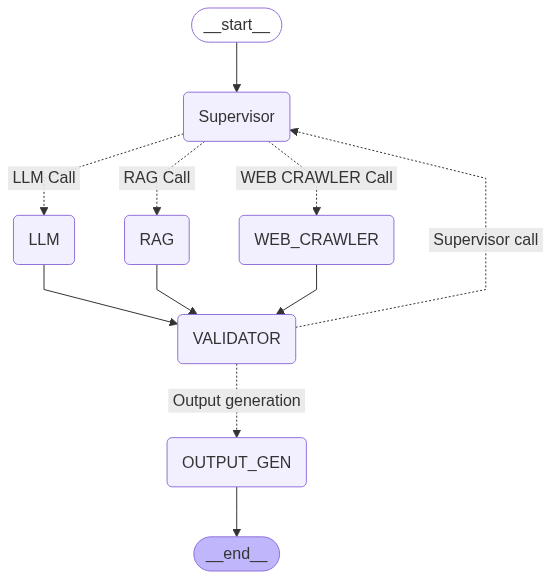

In [53]:
from IPython.display import display, Image

display(Image(app.get_graph().draw_mermaid_png()))

In [57]:
state={"messages":["what will the weather in dec in India 2025 and Jan 2024?"]}

In [58]:
result=app.invoke(state)

-> SUPERVISOR ->
INITIAL CALL - Question: what will the weather in dec in India 2025 and Jan 2024?
Supervisor decision: WEB_SEARCH
-> ROUTER ->
Last message: WEB_SEARCH
-> WEB Search ->
Web search result: Based on the provided search results:

* **December 2025 in India:**  Expect hot, sunny weather.  Temperatures vary regionally, ranging from 23°C (New Delhi) to 33°C (Goa).  Little to no rain is expected.

* **January 2024 in India:** The provided PDF only mentions a weather forecast for the first two weeks of January 2024,  detailing weather systems and precipitation but not specific temperatures.  More detailed information is needed for a complete picture.
-> VALIDATOR ->
Validation Status: VALID
-> OUTPUT ROUTER ->
Validation result: Validation: VALID
Retry count: 0
✅ Validation passed - Moving to output generation
-> OUTPUT GEN ->


In [ ]:
result

{'messages': ['what will the weather in dec in India 2025 and Jan 2024?',
  'WEB_SEARCH',
  'Based on the provided search results:\n\n* **December 2025 in India:**  Expect hot, sunny weather.  Temperatures vary regionally, ranging from 23°C (New Delhi) to 33°C (Goa).  Little to no rain is expected.\n\n* **January 2024 in India:** The provided PDF only mentions a weather forecast for the first two weeks of January 2024,  detailing weather systems and precipitation but not specific temperatures.  More detailed information is needed for a complete picture.',
  'Validation: VALID',
  'Validation: VALID']}

Bad pipe message: %s [b'>\xc6\xfd\x8cY\xf3\x87\x11%\xed\xfa\xaa\xef\xd5\xaa\xb2f\xdc\x00\x01|\x00\x00\x00\x01\x00\x02\x00\x03\x00\x04\x00\x05\x00\x06\x00\x07\x00\x08\x00\t\x00\n\x00\x0b\x00\x0c\x00\r\x00\x0e\x00\x0f\x00\x10\x00\x11\x00\x12\x00\x13\x00\x14\x00\x15\x00\x16\x00\x17\x00\x18\x00\x19\x00\x1a\x00\x1b\x00/\x000\x001\x002\x003\x004\x005\x006\x007\x008\x009\x00:\x00;\x00<\x00=\x00>\x00?\x00@\x00A\x00B\x00C\x00D\x00E\x00F\x00g\x00h\x00i\x00j\x00k\x00l\x00m\x00\x84\x00\x85\x00\x86\x00\x87\x00\x88\x00\x89\x00\x96\x00\x97\x00\x98\x00\x99\x00\x9a\x00\x9b\x00\x9c\x00\x9d\x00\x9e\x00\x9f\x00\xa0\x00\xa1']
Bad pipe message: %s [b'\xcd\xe2B\xcb\xadz\xa5dKB\x0fx\xe5\x86\xc9\xdd\xd0G\x00\x01|\x00\x00\x00\x01\x00\x02\x00\x03\x00\x04\x00\x05\x00\x06\x00\x07\x00\x08\x00\t\x00\n\x00\x0b\x00\x0c\x00\r\x00\x0e\x00\x0f\x00\x10\x00\x11\x00\x12\x00\x13\x00\x14\x00\x15\x00\x16\x00\x17\x00\x18\x00\x19\x00\x1a\x00\x1b\x00/\x000\x001\x002\x003\x004\x005\x006\x007\x008\x009\x00:\x00;\x00<\x00=\x00>\x00?